# 규칙 세계 v2 — 경험으로 판단을 배우기 (N2 분석)

이 노트북은 **분석과 그래프 전용**이다. 계산 로직은 `src/cognitive_lab/world2/`에 있고, 여기서는 그걸 불러서 결과만 본다.

필요한 결과 파일은 아래 명령으로 만든다 (seed 42–47).

```cmd
python -m cognitive_lab.world2 generate --seed 42
python -m cognitive_lab.world2.neural_judge --seed 42
python -m cognitive_lab.world2.neural_judge --seed 42 --no-memory
python -m cognitive_lab.world2 score --agent n2 --seed 42
```

질문: **판단 규칙을 알려주지 않았을 때, 신경망이 "어떻게 공부할지"를 스스로 배워서 수학적으로 최적인 학습자에 도달하는가?**

In [16]:
import matplotlib.pyplot as plt
from cognitive_lab.world2 import analysis as A

plt.rcParams["font.family"] = "Malgun Gothic"  # 한글 표시 (Windows)
plt.rcParams["axes.unicode_minus"] = False
AGENTS = ["o2", "b1-equal", "b2-learn", "b2-forget", "b3-bayes", "b3-bayes-h01", "n2-no-memory", "n2"]

## 1. 이상적인 판단과 이상적인 공부 — 수학

사람 $s$의 정확도 수준을 $\ell \in L = \{0.95, 0.75, 0.5, 0.2\}$, 사전분포를 $\pi(\ell)$(균등)이라 하자. 진짜 열쇠 $T$가 주어졌을 때 한 문장의 가능도는 다음과 같다.

$$
P(\text{긍정 } c \mid T,\ell)=\begin{cases}\ell & c=T\\ \frac{1-\ell}{2} & c\ne T\end{cases}
\qquad
P(\text{부정 } n \mid T,\ell)=\begin{cases}\frac{\ell}{2} & n\ne T\\ 1-\ell & n=T\end{cases}
$$

문장이 진실과 맞으면 "맞음"이라 하자(긍정이면 $c=T$, 부정이면 $n\ne T$). 그러면 모든 경우에 가능도는 $\ell\cdot\text{상수}$(맞음) 또는 $(1-\ell)\cdot\text{상수}$(틀림)이고, 상수는 $\ell$과 무관하다. 그래서 피드백으로 $T$를 알게 되면

$$
P(\ell \mid \text{기록}_s) \;\propto\; \pi(\ell)\,\ell^{\,r_s}\,(1-\ell)^{\,w_s}
$$

이다. 즉 **맞은 횟수 $r_s$와 틀린 횟수 $w_s$가 충분통계량**이다. 각 사람의 갱신은 자기 문장만 쓰므로, 사람들 사이의 믿음은 서로 독립으로 남는다.

- **O2 (신탁, 정확도를 앎)**: $P(T=k\mid\text{말들}) \propto \prod_s P(\text{말}_s\mid T=k,\ell_s)$
- **B3 (이상적인 학습자, 정확도를 모름)**: $P(T=k\mid\text{말들},\text{기록}) \propto \prod_s \sum_\ell P(\ell\mid\text{기록}_s)\,P(\text{말}_s\mid T=k,\ell)$
- **변화 대응**: 매 문제 전에 확률 $h$로 수준이 다시 뽑힌다고 보고 $P_t(\ell)=(1-h)P_{t-1}(\ell)+h\,\pi(\ell)$로 거른다(B3-h01은 $h=0.01$, 검증셋으로 선택).
- **답/보류 규칙**: 열쇠 $k$를 답하면 기대 점수는 $2q_k-1$이고, 보류하면 0이다. 따라서 $\max_k q_k>0.5$일 때만 답하는 것이 최적이다.

**N2의 구조**: 사람마다 기억 벡터 $h_s$를 두고, 모든 사람이 같은 가중치의 GRU를 쓴다(사람 순서와 이름에 무관). 증거 머리 $f(h_s)=(a^+_=,a^+_{\ne},a^-_=,a^-_{\ne})$가 열쇠별 로짓에 더해진다(열쇠 순서에 무관). B3는 $a^+_= = \log\sum_\ell P(\ell)\ell$, $a^+_{\ne}=\log\sum_\ell P(\ell)\frac{1-\ell}{2}$ 같은 값이므로 이 함수족 **안에** 있다. N2는 이 값들을 정답 없이, 오직 교차엔트로피(적절한 채점 규칙)로 세션 3000개에서 배운다.

**정직한 근사 표시**: B3는 (1) "네 사람이 모두 같은 수준은 아니다"라는 세계 제약을 무시하고, (2) 정답이 공개되지 않는 다른 문에 대한 말을 학습에 쓰지 않는다. 그래서 정확히는 "질문한 문의 피드백만 쓰는 학습자 중 최적"이다.

In [17]:
rows = A.summary_table(AGENTS)
print(f"{'판단기':14s} {'전체':>14s} {'문제1-10':>14s} {'문제31-40':>14s} {'변화직후10':>14s}")
for r in rows:
    f = lambda m: f"{m[0]:.3f}±{m[1]:.3f}"
    print(f"{r['agent']:14s} {f(r['overall']):>14s} {f(r['episodes_1_10']):>14s} {f(r['episodes_31_40']):>14s} {f(r['after_drift_10']):>14s}")

판단기                        전체         문제1-10        문제31-40         변화직후10
o2                0.443±0.015    0.440±0.018    0.461±0.016    0.456±0.041
b1-equal          0.208±0.019    0.210±0.025    0.207±0.019    0.226±0.046
b2-learn          0.374±0.017    0.321±0.011    0.408±0.022    0.330±0.060
b2-forget         0.372±0.017    0.320±0.012    0.405±0.021    0.363±0.056
b3-bayes          0.375±0.016    0.321±0.012    0.411±0.022    0.330±0.063
b3-bayes-h01      0.380±0.017    0.321±0.012    0.420±0.026    0.364±0.061
n2-no-memory      0.207±0.018    0.209±0.023    0.206±0.018    0.219±0.053
n2                0.376±0.016    0.318±0.013    0.416±0.024    0.355±0.053


## 2. 이상적인 학습자(B3) 대비 차이 — seed 짝 비교, 95% 신뢰구간 (t, 자유도 5)

In [18]:
for agent in ["b2-learn", "b2-forget", "n2-no-memory", "n2"]:
    mean, low, high = A.paired_difference(agent, "b3-bayes-h01")
    print(f"{agent:14s} - B3: {mean:+.4f}   95% CI [{low:+.4f}, {high:+.4f}]")

b2-learn       - B3: -0.0058   95% CI [-0.0082, -0.0034]
b2-forget      - B3: -0.0078   95% CI [-0.0117, -0.0038]
n2-no-memory   - B3: -0.1732   95% CI [-0.1888, -0.1576]
n2             - B3: -0.0042   95% CI [-0.0083, -0.0001]


## 3. 학습 곡선 — 세션 안에서 문제 번호별 평균 점수 (세션 100개 × seed 6개)

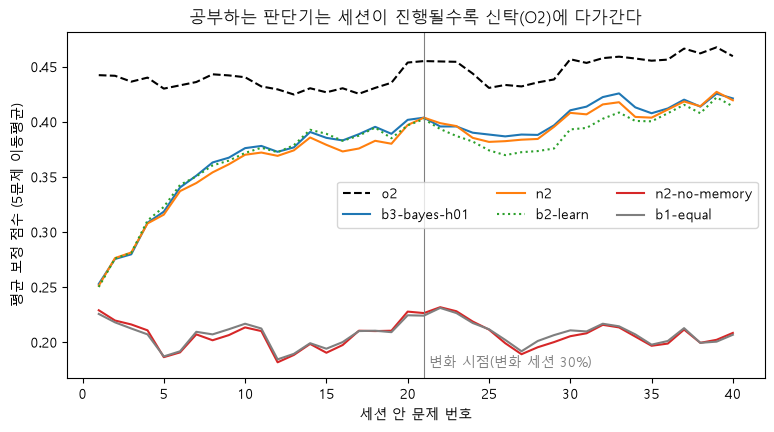

In [19]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for agent, style in [("o2", "k--"), ("b3-bayes-h01", "C0-"), ("n2", "C1-"), ("b2-learn", "C2:"), ("n2-no-memory", "C3-"), ("b1-equal", "C7-")]:
    curve = A.learning_curve(agent)
    smooth = [sum(curve[max(0, i - 2): i + 3]) / len(curve[max(0, i - 2): i + 3]) for i in range(len(curve))]
    ax.plot(range(1, 41), smooth, style, label=agent)
ax.axvline(21, color="gray", lw=0.8)
ax.text(21.3, ax.get_ylim()[0] + 0.01, "변화 시점(변화 세션 30%)", color="gray")
ax.set_xlabel("세션 안 문제 번호"); ax.set_ylabel("평균 보정 점수 (5문제 이동평균)")
ax.legend(ncol=3); ax.set_title("공부하는 판단기는 세션이 진행될수록 신탁(O2)에 다가간다")
plt.show()

## 4. 확률이 정직한가 — 로그 손실과 보정 곡선 (seed 42 시험셋)

log loss  B3 0.7744   N2 0.7761   N2-no-memory 0.9417   (균등 추측 = ln 3 = 1.0986)


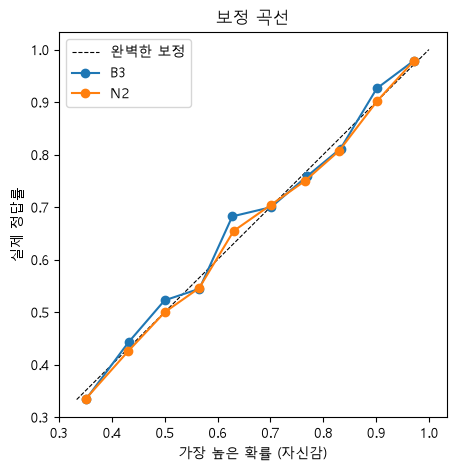

In [20]:
sessions = A.load_sessions(42)
n2 = A.load_n2(42); n2_free = A.load_n2(42, memory=False)
p_n2, truths = A.n2_probabilities(n2, sessions)
p_b3 = A.b3_probabilities(sessions)
p_nomem, _ = A.n2_probabilities(n2_free, sessions)
print("log loss  B3 %.4f   N2 %.4f   N2-no-memory %.4f   (균등 추측 = ln 3 = %.4f)" % (
    A.log_loss(p_b3, truths), A.log_loss(p_n2, truths), A.log_loss(p_nomem, truths), 1.0986))

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([1/3, 1], [1/3, 1], "k--", lw=0.8, label="완벽한 보정")
for name, p in [("B3", p_b3), ("N2", p_n2)]:
    rel = A.reliability(p, truths)
    ax.plot([r[0] for r in rel], [r[1] for r in rel], "o-", label=name)
ax.set_xlabel("가장 높은 확률 (자신감)"); ax.set_ylabel("실제 정답률"); ax.legend(); ax.set_title("보정 곡선")
plt.show()

## 5. N2는 무엇을 배웠나 — 사람별 신뢰 추정의 시간 변화

N2의 "암묵적 정확도"는 긍정 문장 증거를 베이즈 형태로 되돌려 구한다: $e^{a^+_=-a^+_{\ne}}=\frac{p}{(1-p)/2}\Rightarrow p=\frac{r}{2+r}$.
아래는 정확도가 중간에 바뀌는 시험 세션 하나다. 점선은 진짜 정확도, 실선은 B3, 점은 N2다.

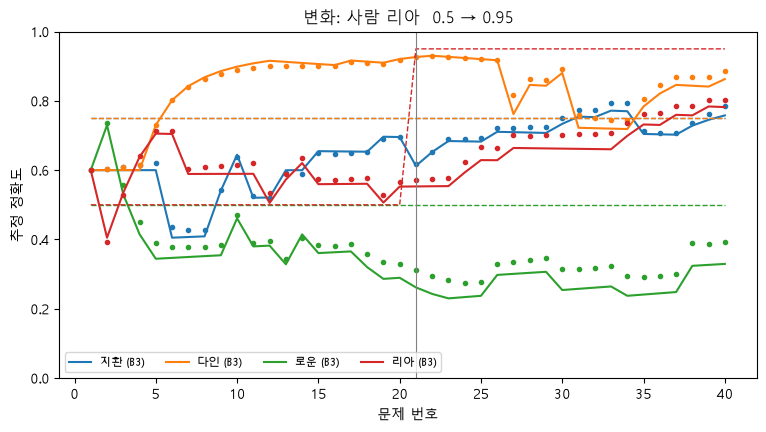

In [21]:
session = next(s for s in sessions if s["hidden"]["drift"])
traj = A.trust_trajectories(session, n2)
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, name in enumerate(traj["speakers"]):
    color = f"C{i}"
    ax.plot(range(1, 41), [t[i] for t in traj["true"]], "--", color=color, lw=1)
    ax.plot(range(1, 41), [t[i] for t in traj["b3"]], "-", color=color, label=f"{name} (B3)")
    ax.plot(range(1, 41), [t[i] for t in traj["n2"]], ".", color=color)
ax.axvline(traj["drift"]["at"] + 1, color="gray", lw=0.8)
ax.set_ylim(0, 1); ax.set_xlabel("문제 번호"); ax.set_ylabel("추정 정확도")
ax.legend(ncol=4, fontsize=8); ax.set_title(f"변화: 사람 {traj['speakers'][traj['drift']['speaker']]}  {traj['drift']['from']} → {traj['drift']['to']}")
plt.show()

## 6. 해석 메모

- 아래 수치는 노트북을 실행한 결과로 확인한다. 같은 내용은 설계 문서 `design/world-v2-learning-to-judge.md`에도 기록한다.
- 결론을 쓸 때 지킬 것: seed 6개 짝 비교의 신뢰구간이 0을 포함하면 "차이 없음"이 아니라 "차이를 확인하지 못함"으로 쓴다.


## 7. 부분 피드백: "맞았다/틀렸다"만 알려줄 때

답하면 맞았는지 틀렸는지만 듣고, `모름`이라고 하면 아무것도 듣지 못한다. 그러면 B3의 횟수 통계가 더 이상 충분하지 않다. "틀렸다"를 들어도 정답 후보가 둘 남아서 사람들 사이의 판단이 얽히기 때문이다. 대신 정확도 수준 배정 전체 $z\in L^4$(256가지)에 대한 **결합 사후분포**를 정확히 추적한다(B4). 문제마다 $L[z,k]=\prod_s P(\text{말}_s\mid T=k,\ell_s(z))$를 계산하고 다음처럼 갱신한다.

$$
b(z)\leftarrow b(z)\cdot\begin{cases}
L[z,T] & \text{정답을 앎 (맞음 피드백 포함)}\\
\sum_{T\ne k} L[z,T] & \text{답 }k\text{가 틀림}\\
\sum_{T} L[z,T] & \text{보류 (피드백 없음)}
\end{cases}
$$

마지막 경우가 중요하다. 피드백이 없어도 **말들이 서로 맞는지**가 정확도에 대한 정보가 된다. B4는 생성 과정의 사전분포("네 명이 모두 같지는 않음")와 변화 규칙(21번째 문제에서 30% 확률로 한 명이 바뀜)도 정확히 반영한다. 그래서 정답 피드백을 줄 때도 B3보다 약간 낫다.

**믿음은 정확하지만 정책은 근시안적이다.** 지금 답할지는 이번 문제의 기대 점수만 보고 정한다. "답해서 배울 정보의 가치"까지 최적화하는 것은 POMDP이고, 여기서는 탐색 휴리스틱(초반 문제에서는 기준값을 낮춤)을 검증셋에서 골라 비교한다.

N2-partial은 기억 입력에 $\text{soft\_right}_s=\sum_k q'_k\,\mathbf 1[\text{말}_s\text{가 맞음}\mid T=k]$를 받는다. 여기서 $q'$은 피드백으로 조건화한 자기 예측이다. EM 알고리즘의 기대 충분통계량과 같은 역할이다.


In [22]:
import json, statistics
from cognitive_lab.world2.analysis import RESULTS_DIR, SEEDS

ROWS = [
    ("O2 신탁 (정확도 앎)", "o2", ""),
    ("B4 결합 베이즈, 정답 피드백", "b4-joint", ""),
    ("B3-h01, 정답 피드백", "b3-bayes-h01", ""),
    ("B4 결합 베이즈, 부분 피드백", "b4-joint", "_partial"),
    ("B4 + 탐색(10문제, 0.45), 부분", "b4-joint", "_partial_explore-10-0.45"),
    ("N2-partial, 부분 피드백", "n2-partial", "_partial"),
    ("B2-partial 횟수 세기, 부분", "b2-partial", "_partial"),
]

def path(agent, suffix, seed):
    return RESULTS_DIR / f"world-v2_{agent}_test_seed-{seed}{suffix}.json"

# Use only seeds for which every row has a result, so a partly finished run still works.
seeds = [s for s in SEEDS if all(path(a, x, s).exists() for _, a, x in ROWS)]
if len(seeds) < 2:
    raise RuntimeError(f"부분 피드백 결과가 있는 seed가 {len(seeds)}개뿐이다. 실행이 끝난 뒤 다시 돌린다.")
print(f"사용한 seed: {seeds} ({len(seeds)}/{len(SEEDS)})")

def load(agent, suffix=""):
    return [json.loads(path(agent, suffix, s).read_text(encoding="utf-8")) for s in seeds]

t_quantile = {2: 12.706, 3: 4.303, 4: 3.182, 5: 2.776, 6: 2.571}[len(seeds)]
f = lambda xs: f"{statistics.mean(xs):.3f}±{statistics.stdev(xs):.3f}"
print(f"{'판단기':30s} {'전체':>14s} {'문제1-10':>14s} {'문제31-40':>14s}")
for name, agent, suffix in ROWS:
    results = load(agent, suffix)
    print(f"{name:30s} {f([r['overall']['mean_score'] for r in results]):>14s} "
          f"{f([r['by_episode_bucket']['1-10']['mean_score'] for r in results]):>14s} "
          f"{f([r['by_episode_bucket']['31-40']['mean_score'] for r in results]):>14s}")

def paired(a, b):
    d = [x["overall"]["mean_score"] - y["overall"]["mean_score"] for x, y in zip(a, b)]
    m = statistics.mean(d); h = t_quantile * statistics.stdev(d) / len(d) ** 0.5
    return f"{m:+.4f} [{m - h:+.4f}, {m + h:+.4f}]"

b4p = load("b4-joint", "_partial")
print(f"\n부분 피드백 B4 대비 (seed 짝, 95% CI, t 자유도 {len(seeds) - 1})")
print("  탐색 휴리스틱:", paired(load("b4-joint", "_partial_explore-10-0.45"), b4p))
print("  N2-partial    :", paired(load("n2-partial", "_partial"), b4p))
print("  B2-partial    :", paired(load("b2-partial", "_partial"), b4p))
print("정보 손실 (정답 피드백 B4 - 부분 피드백 B4):", paired(load("b4-joint"), b4p))

사용한 seed: [42, 43, 44] (3/6)
판단기                                        전체         문제1-10        문제31-40
O2 신탁 (정확도 앎)                     0.441±0.021    0.451±0.018    0.459±0.023
B4 결합 베이즈, 정답 피드백                 0.377±0.021    0.321±0.014    0.430±0.030
B3-h01, 정답 피드백                    0.376±0.023    0.321±0.017    0.424±0.039
B4 결합 베이즈, 부분 피드백                 0.356±0.021    0.288±0.015    0.419±0.027
B4 + 탐색(10문제, 0.45), 부분           0.357±0.021    0.294±0.009    0.417±0.031
N2-partial, 부분 피드백                0.354±0.020    0.289±0.008    0.414±0.027
B2-partial 횟수 세기, 부분              0.347±0.022    0.287±0.019    0.399±0.035

부분 피드백 B4 대비 (seed 짝, 95% CI, t 자유도 2)
  탐색 휴리스틱: +0.0015 [-0.0017, +0.0046]
  N2-partial    : -0.0022 [-0.0046, +0.0003]
  B2-partial    : -0.0093 [-0.0220, +0.0033]
정보 손실 (정답 피드백 B4 - 부분 피드백 B4): +0.0213 [+0.0193, +0.0233]
